# Figure 4 — Candidate regulatory mechanisms × VCV mode

Generates panels **B**, **C**, **D** of Figure 4. Panel A (VCV=0 vs VCV=1 schematic) is built separately.

- **B** — endpoint-metrics grid: 5 metrics × 5 regulatory dynamics × 2 VCV modes, with experimental *mud* IQR overlaid.
- **C** — representative *mud* lineages (50th percentile by lineage area) for {unregulated, NB-contact, volume-ABM, volume-PDE} × {VCV=0, VCV=1}.
- **D** — the closest-to-experimental VCV=0 mechanism vs the closest-to-experimental VCV=1 mechanism vs experimental *mud*, across all five calibration metrics.

`mudmut_divMean0Stdev50_rotMean0Stdev30` is the only *mud* condition used here. vcv1_* = VCV=1, vcv0_* = VCV=0; within each block: noreg=NONE, nb_abm=NB-ABM, vol_abm=VOL-ABM, nb_pde=NB-PDE, vol_pde=VOL-PDE.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "npa").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from npa.sim_viz import load_raw_snapshot_full, render_raw

FIG_DIR = REPO_ROOT / "docs" / "tex_draft" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

_style_dir = str(REPO_ROOT / "docs" / "tex_draft")
if _style_dir not in sys.path:
    sys.path.insert(0, _style_dir)
from _style import RCPARAMS as _RCPARAMS, FONT_SIZE_TITLE, FONT_SIZE_LABEL, EXP_FILL_COLOR, EXP_MEDIAN_COLOR
mpl.rcParams.update(_RCPARAMS)

print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {FIG_DIR}")


Repo root: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis
Output dir: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures


In [2]:
DS_UM_PER_VOX = 0.3
AREA_SCALE = DS_UM_PER_VOX ** 2

MUD_CONDITION = "mudmut_divMean0Stdev50_rotMean0Stdev30"

# (sim_id, VCV, regulatory_dynamic)
SIM_MAP: list[tuple[str, int, str]] = [
    ("vcv1_noreg",  1, "NONE"),
    ("vcv1_nb_abm", 1, "NB-ABM"),
    ("vcv1_vol_abm", 1, "VOL-ABM"),
    ("vcv1_nb_pde", 1, "NB-PDE"),
    ("vcv1_vol_pde", 1, "VOL-PDE"),
    ("vcv0_noreg",  0, "NONE"),
    ("vcv0_nb_abm", 0, "NB-ABM"),
    ("vcv0_vol_abm", 0, "VOL-ABM"),
    ("vcv0_nb_pde", 0, "NB-PDE"),
    ("vcv0_vol_pde", 0, "VOL-PDE"),
]

DYNAMIC_ORDER = ["NONE", "NB-ABM", "NB-PDE", "VOL-ABM", "VOL-PDE"]
DYNAMIC_LABELS = {
    "NONE": "none",
    "NB-ABM": "NB ABM",
    "NB-PDE": "NB PDE",
    "VOL-ABM": "Vol ABM",
    "VOL-PDE": "Vol PDE",
}

# Subset shown in panel C
PANEL_C_DYNAMICS = ["NONE", "NB-ABM", "NB-PDE", "VOL-ABM", "VOL-PDE"]
PANEL_C_LABELS = {
    "NONE": "unregulated",
    "NB-ABM": "NB contact (ABM)",
    "NB-PDE": "NB contact (PDE)",
    "VOL-ABM": "volume (ABM)",
    "VOL-PDE": "volume (PDE)",
}

VCV_FILL = {0: "#d9d9d9", 1: "#5f5f5f"}
EXP_BAND_COLOR = EXP_MEDIAN_COLOR
EXP_BAND_ALPHA = 0.13

WT_CONDITION = "wt_divMean0Stdev26"
WT_SIM_ID = "vcv1_vol_abm"
WT_VCV = 1

METRIC_SPECS = [
    ("lin_area_vox", "Lineage area", "µm²", True),
    ("dpn_area_vox", "Total NB area", "µm²", True),
    ("avg_dpn_area_vox", "Mean NB area", "µm²/cell", True),
    ("n_pros", "Pros count", "cells", False),
    ("n_dpn", "NB count", "cells", False),
]

SIM_METRICS_CSV = REPO_ROOT / "data" / "sim" / "processed_sweep" / "sim_metrics_last.csv"
SIM_RUN_INDEX_CSV = REPO_ROOT / "data" / "sim" / "processed_sweep" / "sim_run_index.csv"
EXP_INDEX_CSV = REPO_ROOT / "data" / "exp" / "processed" / "lineage_index.csv"
EXP_ANALYSIS_DIR = REPO_ROOT / "data" / "exp" / "processed" / "analysis"


In [3]:
sim_df = pd.read_csv(SIM_METRICS_CSV)
run_index_df = pd.read_csv(SIM_RUN_INDEX_CSV)
exp_index_df = pd.read_csv(EXP_INDEX_CSV)

sim_id_to_meta = {sid: (vcv, dyn) for sid, vcv, dyn in SIM_MAP}
mud = sim_df.loc[
    (sim_df["condition"] == MUD_CONDITION)
    & (sim_df["sim_id"].isin([sid for sid, _, _ in SIM_MAP]))
].copy()
mud["VCV"] = mud["sim_id"].map(lambda s: sim_id_to_meta[s][0])
mud["dynamic"] = mud["sim_id"].map(lambda s: sim_id_to_meta[s][1])

wt_runs = sim_df.loc[
    (sim_df["condition"] == WT_CONDITION)
    & (sim_df["sim_id"] == WT_SIM_ID)
    & (sim_df["critical_volume_mode"] == WT_VCV)
].copy()


def attach_exp_analysis(genotype: str) -> pd.DataFrame:
    analysis_path = EXP_ANALYSIS_DIR / f"{genotype}.npz"
    selected = (
        exp_index_df.loc[exp_index_df["genotype"] == genotype]
        .copy()
        .sort_values("analysis_row")
        .reset_index(drop=True)
    )
    with np.load(analysis_path) as data:
        selected["lin_area_vox"] = data["geo"].sum(axis=(1, 2, 3))
        selected["dpn_area_vox"] = data["counts"][:, 2]
    selected["avg_dpn_area_vox"] = selected["dpn_area_vox"] / selected["n_dpn"].clip(lower=1)
    return selected


exp_mud = attach_exp_analysis("mudmut")
exp_wt = attach_exp_analysis("wt")

print(f"mud rows: {len(mud)} ({mud['sim_id'].nunique()} sim_ids, "
      f"VCV={sorted(mud['VCV'].unique())}, "
      f"dynamics={sorted(mud['dynamic'].unique())})")
print(f"experimental mud lineages: {len(exp_mud)}")


mud rows: 500 (10 sim_ids, VCV=[np.int64(0), np.int64(1)], dynamics=['NB-ABM', 'NB-PDE', 'NONE', 'VOL-ABM', 'VOL-PDE'])
experimental mud lineages: 59


In [4]:
def content_bbox(arr: np.ndarray, pad: int = 6) -> tuple[int, int, int, int]:
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0:
        h, w = arr.shape[:2]
        return 0, 0, h, w
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, arr.shape[1])
    return y0, x0, y1, x1


def uniform_crop_size(snapshots: list, pad: int = 6) -> int:
    """Maximum square dimension across all geo_raw arrays in `snapshots`."""
    max_dim = 0
    for geo_raw, *_ in snapshots:
        y0, x0, y1, x1 = content_bbox(geo_raw, pad=pad)
        max_dim = max(max_dim, y1 - y0, x1 - x0)
    return max_dim


def crop_centered(arr: np.ndarray, target_size: int) -> np.ndarray:
    """Square crop of size `target_size` centered on the array's content."""
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0:
        cy, cx = arr.shape[0] // 2, arr.shape[1] // 2
    else:
        cy = (int(ys.min()) + int(ys.max())) // 2
        cx = (int(xs.min()) + int(xs.max())) // 2
    half = target_size // 2
    y0 = max(0, min(cy - half, arr.shape[0] - target_size))
    x0 = max(0, min(cx - half, arr.shape[1] - target_size))
    if arr.ndim == 3:
        return arr[y0:y0 + target_size, x0:x0 + target_size, :]
    return arr[y0:y0 + target_size, x0:x0 + target_size]


def metric_values(df: pd.DataFrame, key: str, is_area: bool) -> np.ndarray:
    v = df[key].astype(float).to_numpy()
    return v * AREA_SCALE if is_area else v


def pick_percentile_run(df: pd.DataFrame, metric: str, percentile: float) -> pd.Series:
    target = df[metric].quantile(percentile)
    candidates = df.assign(abs_delta=(df[metric] - target).abs()).sort_values(
        ["abs_delta", metric, "run_id"], kind="stable"
    )
    return candidates.iloc[0]


def load_run_snapshot(condition: str, sim_id: str, run_id: int) -> tuple[np.ndarray, np.ndarray]:
    row = run_index_df.loc[
        (run_index_df["condition"] == condition)
        & (run_index_df["sim_id"] == sim_id)
        & (run_index_df["run_id"].astype(int) == int(run_id))
    ].iloc[0]
    cells_path = REPO_ROOT / row["cells_path"]
    locs_path = REPO_ROOT / row["locs_path"]
    return load_raw_snapshot_full(cells_path, locs_path)


def style_publication_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#d0d0d0", linewidth=0.6, alpha=0.5)
    ax.tick_params(axis="x", length=0)


## Panel B — endpoint metrics grid

Five metrics across the top, 5 regulatory dynamics on each x-axis, two boxes per dynamic (light = VCV=0, dark = VCV=1). The shaded red band is the experimental *mud* IQR; the dashed red line is the experimental *mud* median. The eye should pick up VCV=0 vs VCV=1 first, then differences across dynamics.


saved /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure4_metrics_grid_panel.png


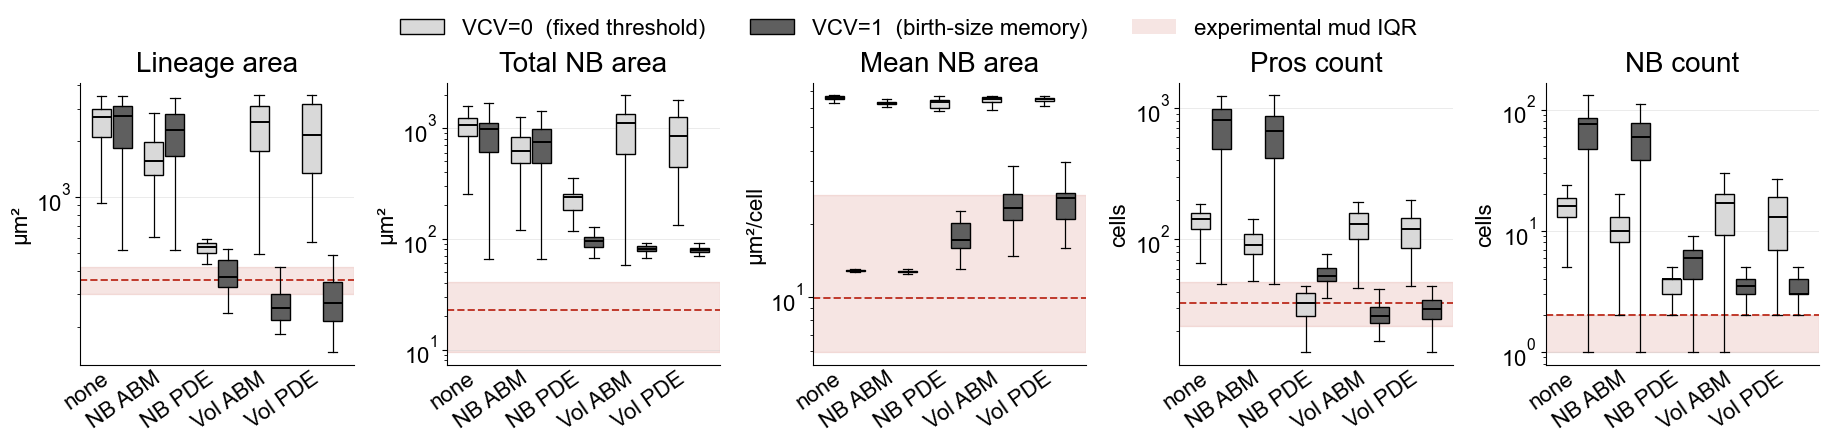

In [5]:
def panel_b() -> plt.Figure:
    fig, axes = plt.subplots(1, len(METRIC_SPECS), figsize=(18.4, 4.7))
    box_width = 0.36
    group_centers = np.arange(1, len(DYNAMIC_ORDER) + 1, dtype=float)

    for ax, (key, title, unit, is_area) in zip(axes, METRIC_SPECS):
        for vcv, offset in [(0, -box_width / 2 - 0.02), (1, +box_width / 2 + 0.02)]:
            values = [
                metric_values(mud.loc[(mud["dynamic"] == d) & (mud["VCV"] == vcv)], key, is_area)
                for d in DYNAMIC_ORDER
            ]
            positions = group_centers + offset
            ax.boxplot(
                values,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "black", "linewidth": 1.4},
                boxprops={"facecolor": VCV_FILL[vcv], "edgecolor": "black", "linewidth": 1.0},
                whiskerprops={"color": "black", "linewidth": 0.9},
                capprops={"color": "black", "linewidth": 0.9},
                manage_ticks=False,
                zorder=3,
            )

        exp_vals = metric_values(exp_mud, key, is_area)
        med = float(np.median(exp_vals))
        q25, q75 = np.percentile(exp_vals, [25, 75])
        ax.axhspan(q25, q75, color=EXP_BAND_COLOR, alpha=EXP_BAND_ALPHA, zorder=1)
        ax.axhline(med, color=EXP_BAND_COLOR, linewidth=1.4, linestyle="--", zorder=2)

        ax.set_xticks(group_centers, [DYNAMIC_LABELS[d] for d in DYNAMIC_ORDER])
        ax.set_xlim(0.4, len(DYNAMIC_ORDER) + 0.6)
        ax.set_yscale("log")
        ax.set_title(title, fontsize=FONT_SIZE_TITLE, pad=8)
        ax.set_ylabel(unit)
        ax.tick_params(axis="x", pad=2)
        for label in ax.get_xticklabels():
            label.set_rotation(35)
            label.set_ha("right")
        style_publication_axis(ax)

    handles = [
        Patch(facecolor=VCV_FILL[0], edgecolor="black", label="VCV=0  (fixed threshold)"),
        Patch(facecolor=VCV_FILL[1], edgecolor="black", label="VCV=1  (birth-size memory)"),
        Patch(facecolor=EXP_BAND_COLOR, alpha=EXP_BAND_ALPHA, label="experimental mud IQR"),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        fontsize=FONT_SIZE_LABEL,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.subplots_adjust(left=0.05, right=0.995, top=0.84, bottom=0.24, wspace=0.34)
    return fig


fig_b = panel_b()
path_b_png = FIG_DIR / "figure4_metrics_grid_panel.png"
path_b_pdf = FIG_DIR / "figure4_metrics_grid_panel.pdf"
fig_b.savefig(path_b_png, bbox_inches="tight", facecolor="white")
fig_b.savefig(path_b_pdf, bbox_inches="tight", facecolor="white")
print(f"saved {path_b_png}")
plt.show()

## Panel C — representative lineages

50th-percentile-by-lineage-area runs from each (regulatory dynamic × VCV) combination. Top row VCV=1, bottom row VCV=0. `PANEL_C_DYNAMICS` controls which 4 dynamics are shown — swap NB-PDE for NB-ABM in the constants cell if you'd rather show the simpler NB rule.


panel C uniform crop: 200x200 voxels (60.0x60.0 µm)


saved /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure4_representative_lineages_panel.png


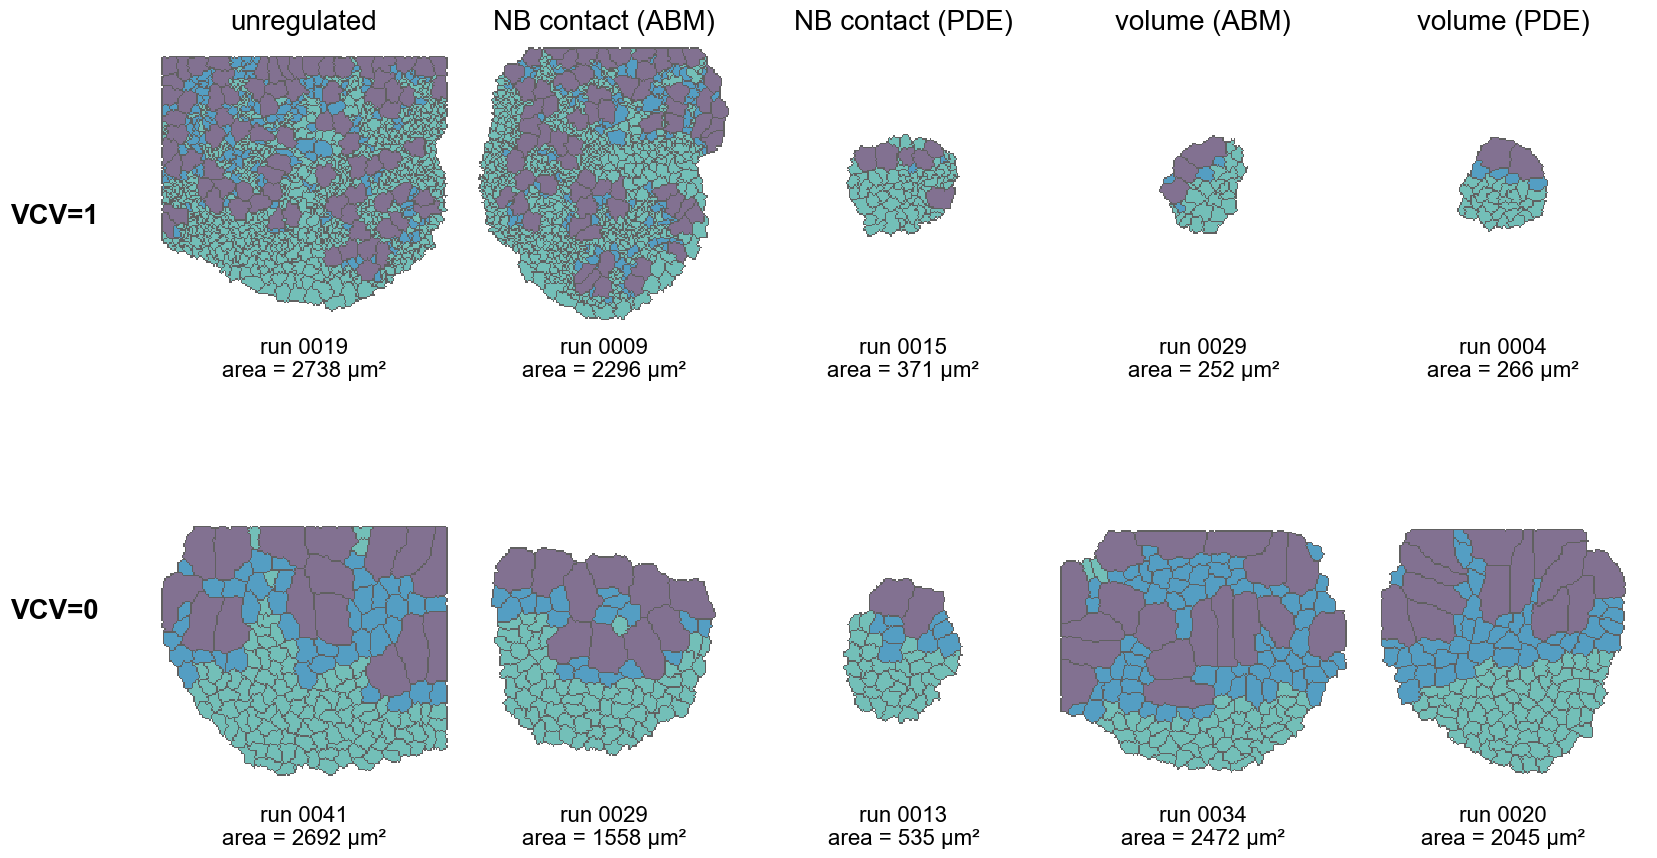

In [6]:
def panel_c() -> plt.Figure:
    fig, axes = plt.subplots(2, len(PANEL_C_DYNAMICS), figsize=(17.4, 9.4))
    sim_id_for = {(dyn, vcv): sid for sid, vcv, dyn in SIM_MAP}

    for col, dyn in enumerate(PANEL_C_DYNAMICS):
        axes[0, col].set_title(PANEL_C_LABELS[dyn], fontsize=FONT_SIZE_TITLE, pad=8)

    # First pass: load all snapshots so we can compute one uniform crop size
    snapshots: list[tuple[int, int, np.ndarray, np.ndarray, pd.Series]] = []
    for row_idx, vcv in enumerate([1, 0]):
        for col, dyn in enumerate(PANEL_C_DYNAMICS):
            sid = sim_id_for[(dyn, vcv)]
            subset = mud.loc[(mud["dynamic"] == dyn) & (mud["VCV"] == vcv)]
            rep = pick_percentile_run(subset, "lin_area_vox", 0.5)
            run_id = int(rep["run_id"])
            geo_raw, label_map = load_run_snapshot(MUD_CONDITION, sid, run_id)
            snapshots.append((row_idx, col, geo_raw, label_map, rep))

    target_size = uniform_crop_size([(g, l) for _, _, g, l, _ in snapshots], pad=6)
    print(f"panel C uniform crop: {target_size}x{target_size} voxels "
          f"({target_size * DS_UM_PER_VOX:.1f}x{target_size * DS_UM_PER_VOX:.1f} µm)")

    for row_idx, col, geo_raw, label_map, rep in snapshots:
        ax = axes[row_idx, col]
        geo_crop = crop_centered(geo_raw, target_size)
        label_crop = crop_centered(label_map, target_size)
        render_raw(geo_crop, ax=ax, label_map=label_crop, title="")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        run_id = int(rep["run_id"])
        ax.set_xlabel(
            f"run {run_id:04d}\narea = {rep['lin_area_vox'] * AREA_SCALE:.0f} µm²",
            fontsize=FONT_SIZE_LABEL,
            labelpad=2,
        )
        ax.xaxis.set_label_coords(0.5, -0.03)

    for row_idx, vcv in enumerate([1, 0]):
        bbox = axes[row_idx, 0].get_position()
        fig.text(
            bbox.x0 - 0.02,
            (bbox.y0 + bbox.y1) / 2,
            f"VCV={vcv}",
            ha="right",
            va="center",
            fontsize=FONT_SIZE_TITLE,
            fontweight="bold",
        )

    fig.subplots_adjust(left=0.14, right=0.995, top=0.93, bottom=0.05, wspace=0.04, hspace=0.30)
    return fig


fig_c = panel_c()
path_c_png = FIG_DIR / "figure4_representative_lineages_panel.png"
path_c_pdf = FIG_DIR / "figure4_representative_lineages_panel.pdf"
fig_c.savefig(path_c_png, bbox_inches="tight", facecolor="white")
fig_c.savefig(path_c_pdf, bbox_inches="tight", facecolor="white")
print(f"saved {path_c_png}")
plt.show()

## Panel D — best VCV=0 vs best VCV=1 vs experimental mud

`best_dynamic(vcv)` selects, among the four regulatory mechanisms (excluding NONE), the dynamic whose median lineage area is closest to the experimental *mud* median. You can override either pick by passing `best_vcv0=...` / `best_vcv1=...` to `panel_d`.


best VCV=0: NB-PDE    best VCV=1: NB-PDE


saved /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure4_best_vs_exp_panel.png


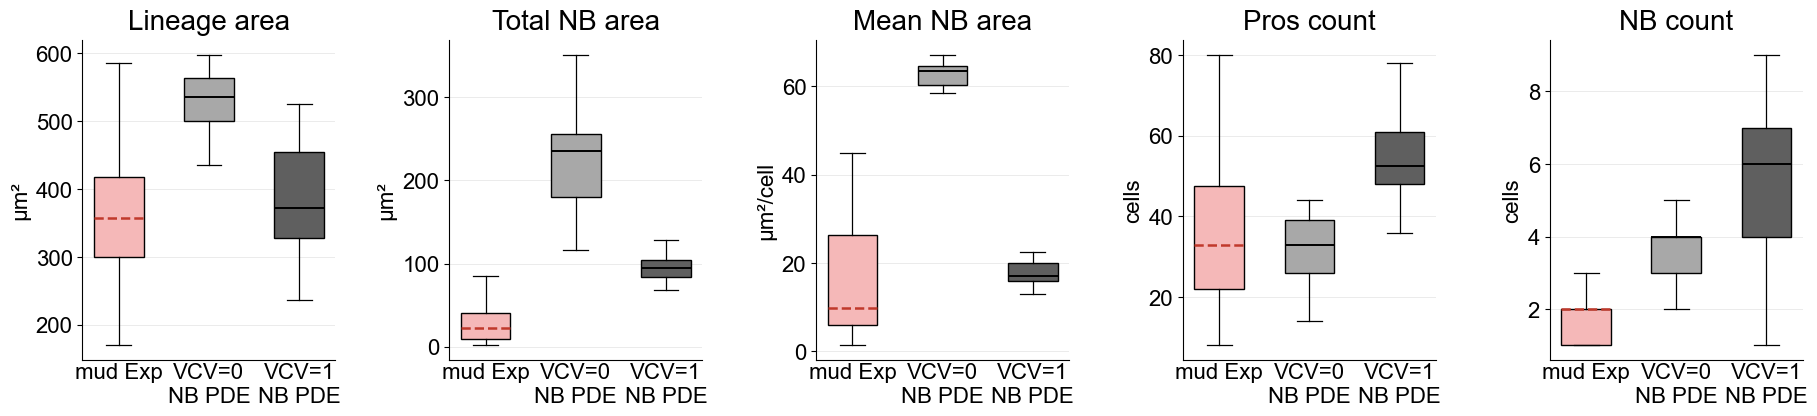

In [7]:
def best_dynamic(vcv: int, key: str = "lin_area_vox", is_area: bool = True) -> str:
    exp_med = float(np.median(metric_values(exp_mud, key, is_area)))
    best_dyn, best_dist = None, float("inf")
    for dyn in DYNAMIC_ORDER:
        if dyn == "NONE":
            continue
        subset = mud.loc[(mud["dynamic"] == dyn) & (mud["VCV"] == vcv)]
        if subset.empty:
            continue
        sim_med = float(np.median(metric_values(subset, key, is_area)))
        dist = abs(sim_med - exp_med)
        if dist < best_dist:
            best_dist = dist
            best_dyn = dyn
    return best_dyn


def panel_d(best_vcv0: str | None = None, best_vcv1: str | None = None) -> plt.Figure:
    if best_vcv0 is None:
        best_vcv0 = best_dynamic(0)
    if best_vcv1 is None:
        best_vcv1 = best_dynamic(1)
    print(f"best VCV=0: {best_vcv0}    best VCV=1: {best_vcv1}")

    fig, axes = plt.subplots(1, len(METRIC_SPECS), figsize=(18.4, 4.7))
    fill_map = {"exp": EXP_FILL_COLOR, "vcv0": "#a8a8a8", "vcv1": "#5f5f5f"}

    for ax, (key, title, unit, is_area) in zip(axes, METRIC_SPECS):
        groups = [
            ("mud Exp", metric_values(exp_mud, key, is_area), fill_map["exp"]),
            (
                f"VCV=0\n{DYNAMIC_LABELS[best_vcv0]}",
                metric_values(mud.loc[(mud["dynamic"] == best_vcv0) & (mud["VCV"] == 0)], key, is_area),
                fill_map["vcv0"],
            ),
            (
                f"VCV=1\n{DYNAMIC_LABELS[best_vcv1]}",
                metric_values(mud.loc[(mud["dynamic"] == best_vcv1) & (mud["VCV"] == 1)], key, is_area),
                fill_map["vcv1"],
            ),
        ]
        positions = np.arange(1, len(groups) + 1, dtype=float)
        bp = ax.boxplot(
            [v for _, v, _ in groups],
            positions=positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.4},
            boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.0},
            whiskerprops={"color": "black", "linewidth": 0.9},
            capprops={"color": "black", "linewidth": 0.9},
            manage_ticks=False,
            zorder=3,
        )
        for patch, (_, _, c) in zip(bp["boxes"], groups):
            patch.set_facecolor(c)
        bp["medians"][0].set(color=EXP_MEDIAN_COLOR, linewidth=1.8, linestyle="--")
        ax.set_xticks(positions, [g[0] for g in groups])
        ax.set_title(title, fontsize=FONT_SIZE_TITLE, pad=8)
        ax.set_ylabel(unit)
        ax.tick_params(axis="x", pad=2)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        style_publication_axis(ax)

    fig.subplots_adjust(left=0.06, right=0.995, top=0.90, bottom=0.22, wspace=0.45)
    return fig


fig_d = panel_d()
path_d_png = FIG_DIR / "figure4_best_vs_exp_panel.png"
path_d_pdf = FIG_DIR / "figure4_best_vs_exp_panel.pdf"
fig_d.savefig(path_d_png, bbox_inches="tight", facecolor="white")
fig_d.savefig(path_d_pdf, bbox_inches="tight", facecolor="white")
print(f"saved {path_d_png}")
plt.show()